In [1]:
pip install tensorflow

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available:  1
2.20.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Divide the dataset into independent and dependent features

In [6]:
X=dataset.iloc[:, 3:13]
y=dataset.iloc[:, 13]

In [7]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [8]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


## Feature Engineering

In [9]:
geography=pd.get_dummies(X['Geography'], drop_first=True)
gender=pd.get_dummies(X['Gender'], drop_first=True)

## Concatenate these variables with dataframe

In [10]:
X=X.drop(['Geography', 'Gender'], axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [11]:
X=pd.concat([X, geography, gender], axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


## Splitting the dataset into Training set and Test set

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=0)

## Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
X_train.shape

(8000, 11)

## Now lets create the ANN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

## Intializing the ANN

In [16]:
classifier=Sequential()

## Adding the input layer

In [17]:
classifier.add(Dense(units=11, activation='relu'))

### Adding the first hidden layer

In [18]:
classifier.add(Dense(units=7, activation='relu'))

### Adding the second hidden layer

In [19]:
classifier.add(Dense(units=6, activation='relu'))

## Adding the output layer

In [20]:
classifier.add(Dense(1, activation='sigmoid'))

In [21]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [22]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

### Early Stopping

In [24]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [25]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8291 - loss: 0.4152 - val_accuracy: 0.8410 - val_loss: 0.3900
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8492 - loss: 0.3623 - val_accuracy: 0.8402 - val_loss: 0.3781
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8552 - loss: 0.3534 - val_accuracy: 0.8410 - val_loss: 0.3816
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8554 - loss: 0.3479 - val_accuracy: 0.8519 - val_loss: 0.3600
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8561 - loss: 0.3473 - val_accuracy: 0.8501 - val_loss: 0.3588
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8604 - loss: 0.3418 - val_accuracy: 0.8478 - val_loss: 0.3678
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8589 - loss: 0.3408 - val_accuracy: 0.8474 - val_loss: 0.3639
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8572 - loss: 0.3430 

In [27]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Summarize history for accuracy

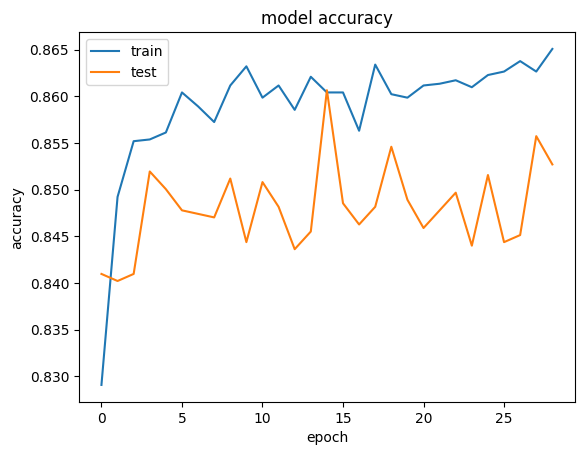

In [28]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Summarize history for loss

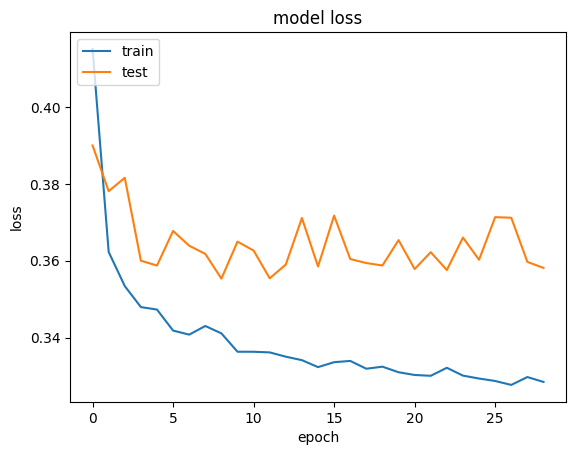

In [29]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Making the predictions and evaluating the model

## Predicting the Test set results

In [30]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


## Make the confusion matrix

In [31]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1498,   97],
       [ 203,  202]])

## Calculate the accuracy

In [32]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.85

### Get the weights

In [34]:
classifier.get_weights()

[array([[-1.2780990e-02,  5.8192793e-02, -1.3463509e-01,  2.0100501e-01,
          6.0769725e-01, -6.1071318e-01,  6.4724669e-02, -8.5855708e-02,
          1.9913288e-02, -5.0406031e-02,  1.4925389e+00],
        [-2.0606279e+00, -2.1641622e+00,  2.9458907e+00, -3.3756561e+00,
         -9.5393300e-01, -2.9151554e+00,  4.3477669e-01,  1.9110638e+00,
          9.8817980e-01, -9.4785340e-02, -2.0292065e+00],
        [ 4.1294169e-01, -5.6648976e-01, -6.2620831e-01, -4.9560043e-01,
          7.1334362e-01, -4.0326342e-01, -2.1466348e-02, -1.4692922e-01,
          5.0120682e-01,  2.1429085e-03,  3.6053690e-03],
        [ 7.0836294e-01,  1.4713229e+00,  6.0235798e-01, -7.1390694e-01,
         -1.6731423e+00, -1.8319762e-01,  2.5841045e-01, -5.8982748e-01,
         -3.1707866e+00, -2.5753787e+00, -1.0140355e+00],
        [ 2.0247295e-01, -1.6312102e+00, -8.6577439e-01,  9.3285359e-02,
         -1.0495197e+00,  3.0224901e-01,  2.7999120e+00, -8.6621773e-01,
         -6.9593191e-02, -3.2709396e+0